In [7]:
# Install dependencies if not installed
!pip install pandas numpy matplotlib seaborn

# --- Import libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

%matplotlib inline

# --- Load the dataset ---
path = r"C:\Users\varsh\Downloads\youtube_channel_info_final_updated.csv"
if not os.path.exists(path):
    print("❌ File not found. Please check the path.")
else:
    df = pd.read_csv(path)
    print("✅ Dataset loaded successfully!")
    display(df.head())

# Standardize column names (lowercase, underscores, no spaces)
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print("\nNormalized column names:\n", df.columns.tolist())


✅ Dataset loaded successfully!


,channel_name,channel_id,view_count,category,country,defaultLanguage,subscriber_count,created_date,description,custom_url,thumbnail,video_count
0,BLACKPINK,UCOmHUn--16B90oW2L6FRR3A,39962585446,"https://en.wikipedia.org/wiki/Music_of_Asia, h...",KR,NaN,99000000,2016-06-29T03:15:23Z,BLACKPINK Official YouTube Channel 블랙핑크 공식 유튜브...,@blackpink,https://yt3.ggpht.com/U3VrCkKjzTpQ3VYv4SCPjNfD...,636
1,HYBE LABELS,UC3IZKseVpdzPSBaWxBxundA,41604896923,"https://en.wikipedia.org/wiki/Hip_hop_music, h...",KR,NaN,78700000,2008-06-04T08:23:22Z,Welcome to the official YouTube channel of HYB...,@hybelabels,https://yt3.ggpht.com/ytc/AIdro_l8g0yRFG8xoe_q...,2817
2,music,UCh7X3QOvvDgBNB80_ILrl9Q,66488,"https://en.wikipedia.org/wiki/Technology, http...",NaN,NaN,179,2017-11-17T05:53:19Z,NaN,@music-lw4ez,https://yt3.ggpht.com/ytc/AIdro_k9GtyIisxdF4aU...,107
3,#SPORTS,UCOtDOEFXsAHu0LTfK1Dejqw,31186,"https://en.wikipedia.org/wiki/Action_game, htt...",NaN,NaN,37,2015-04-03T12:22:45Z,Welcome to one of the most beautiful channel o...,@sports-se7qn,https://yt3.ggpht.com/ytc/AIdro_lbN2EYYIH4TBth...,512
4,BILLIE EILISH,UCVNE660NcgYzi18LwwUZb7Q,14316364,NaN,NaN,NaN,82300,2019-01-18T05:14:32Z,NaN,@billieeilish8477,https://yt3.ggpht.com/ytc/AIdro_n3NfvUAVtcUJvW...,1



Normalized column names:
 ['channel_name', 'channel_id', 'view_count', 'category', 'country', 'defaultlanguage', 'subscriber_count', 'created_date', 'description', 'custom_url', 'thumbnail', 'video_count']


In [8]:
print("Shape of dataset:", df.shape)
print("\nColumn names:\n", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())


Shape of dataset: (9903, 12)

Column names:
 ['channel_name', 'channel_id', 'view_count', 'category', 'country', 'defaultlanguage', 'subscriber_count', 'created_date', 'description', 'custom_url', 'thumbnail', 'video_count']

Data types:
 channel_name        object
channel_id          object
view_count           int64
category            object
country             object
defaultlanguage     object
subscriber_count     int64
created_date        object
description         object
custom_url          object
thumbnail           object
video_count          int64
dtype: object

Missing values:
 channel_name           0
channel_id             0
view_count             0
category             159
country             1556
defaultlanguage     8816
subscriber_count       0
created_date           0
description          856
custom_url            26
thumbnail              0
video_count            0
dtype: int64


In [9]:
df = df.drop_duplicates()
df = df.fillna(0)
print("✅ Cleaned dataset. No missing values remain.")


✅ Cleaned dataset. No missing values remain.


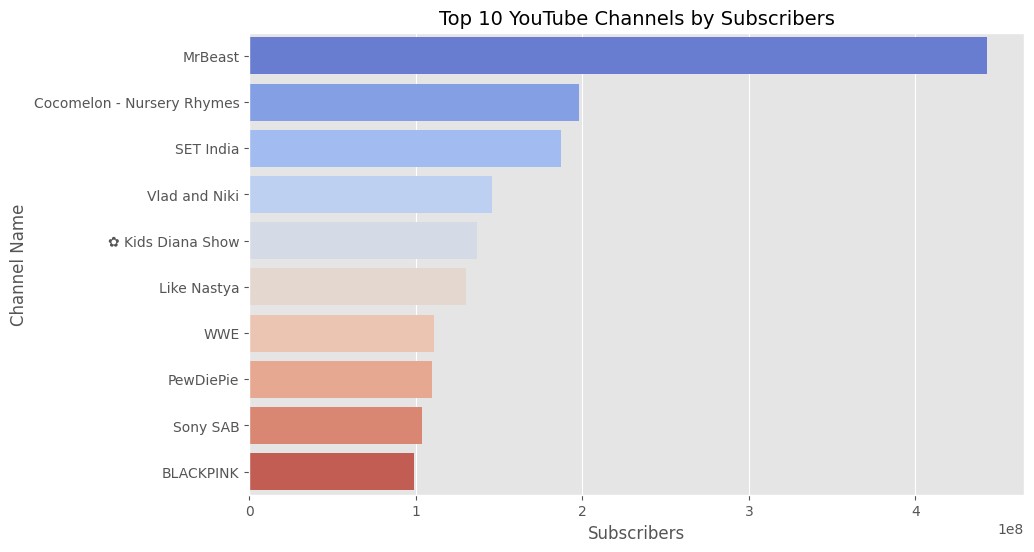

In [15]:
# --- Bar Chart: Top 10 Channels by Subscribers ---
possible_sub_cols = [c for c in df.columns if 'sub' in c]
possible_name_cols = [c for c in df.columns if 'channel' in c or 'name' in c]

if possible_sub_cols and possible_name_cols:
    sub_col = possible_sub_cols[0]
    name_col = possible_name_cols[0]
    
    top_channels = df.sort_values(by=sub_col, ascending=False).head(10)
    plt.figure(figsize=(10,6))
    
    # ✅ Updated line — assigns color by 'name_col' to satisfy Seaborn 0.14+
    sns.barplot(
        x=sub_col, 
        y=name_col, 
        data=top_channels, 
        hue=name_col,         # Added to avoid warning
        dodge=False, 
        legend=False, 
        palette='coolwarm'
    )
    
    plt.title('Top 10 YouTube Channels by Subscribers', fontsize=14)
    plt.xlabel('Subscribers')
    plt.ylabel('Channel Name')
    plt.show()
else:
    print("⚠️ No suitable 'subscribers' or 'channel name' columns found.")


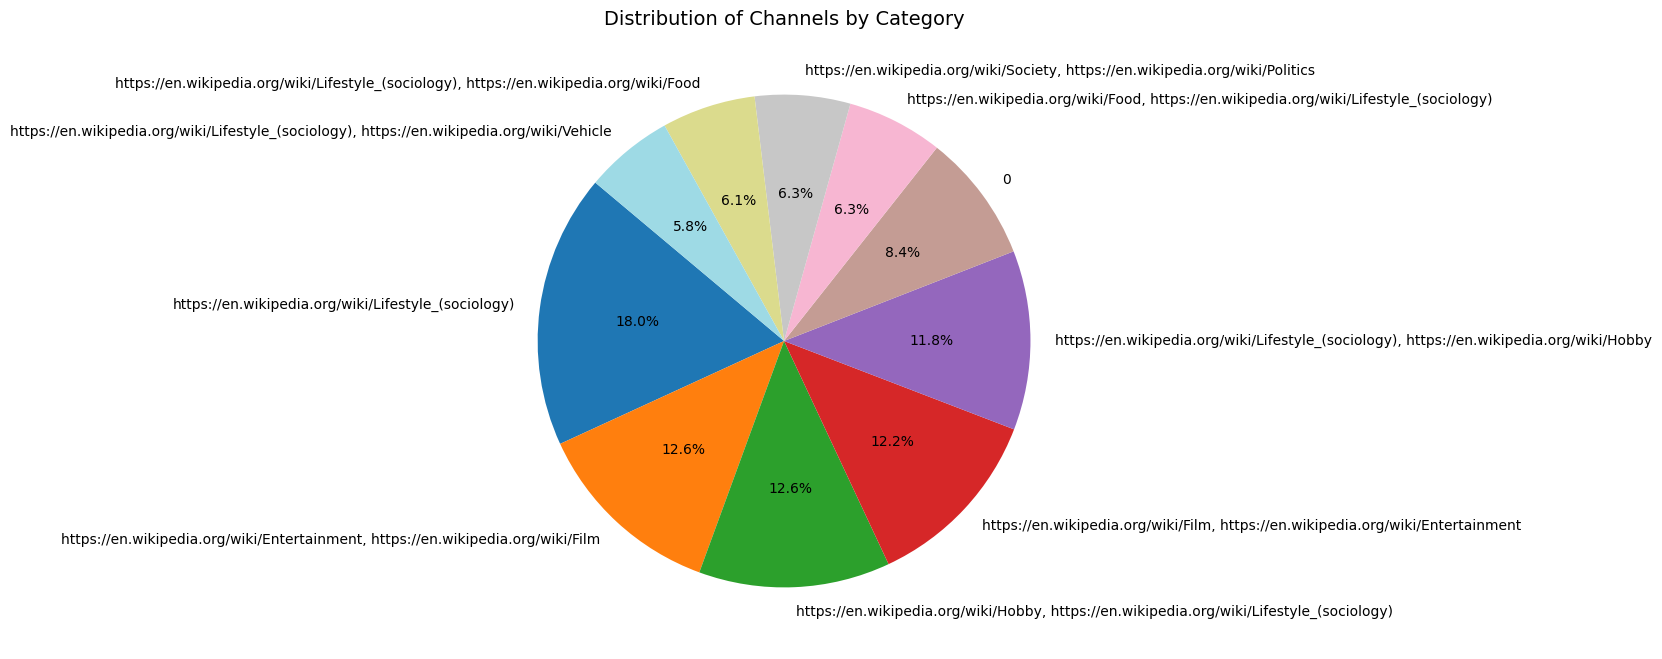

In [11]:
# Detect a 'category' or 'country' column automatically
possible_cat_cols = [c for c in df.columns if 'category' in c or 'genre' in c or 'country' in c or 'type' in c]

if possible_cat_cols:
    cat_col = possible_cat_cols[0]
    plt.figure(figsize=(8,8))
    df[cat_col].value_counts().head(10).plot.pie(autopct='%1.1f%%', startangle=140, cmap='tab20')
    plt.title(f'Distribution of Channels by {cat_col.capitalize()}', fontsize=14)
    plt.ylabel('')
    plt.show()
else:
    print("⚠️ No category-like column found (e.g., 'category', 'country', 'genre').")


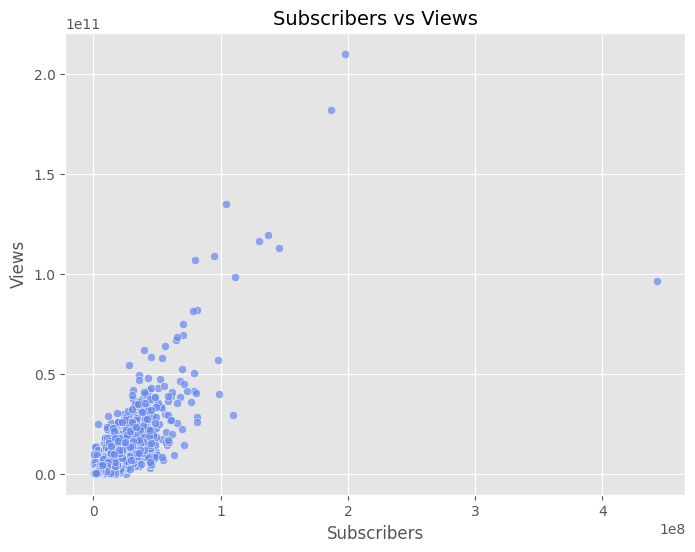

In [12]:
# Try to find columns for subscribers and views automatically
possible_view_cols = [c for c in df.columns if 'view' in c]

if possible_sub_cols and possible_view_cols:
    sub_col = possible_sub_cols[0]
    view_col = possible_view_cols[0]
    
    plt.figure(figsize=(8,6))
    sns.scatterplot(x=sub_col, y=view_col, data=df, alpha=0.7)
    plt.title('Subscribers vs Views', fontsize=14)
    plt.xlabel('Subscribers')
    plt.ylabel('Views')
    plt.show()
else:
    print("⚠️ Could not find both 'subscribers' and 'views' columns.")


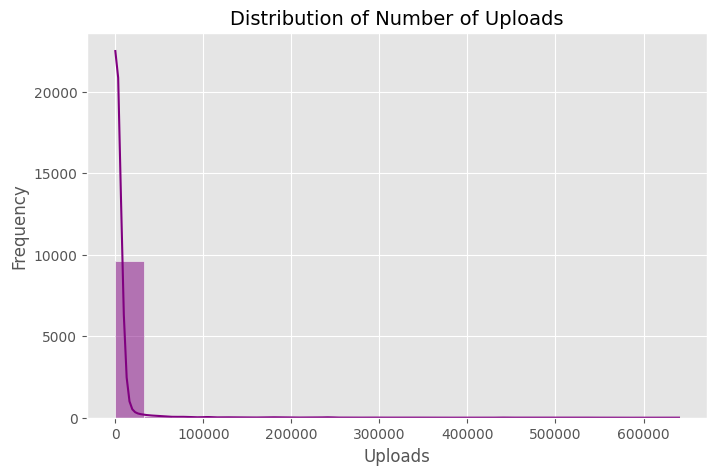

In [13]:
# Detect an 'uploads' or 'videos' column
possible_upload_cols = [c for c in df.columns if 'upload' in c or 'video' in c]

if possible_upload_cols:
    upload_col = possible_upload_cols[0]
    plt.figure(figsize=(8,5))
    sns.histplot(df[upload_col], bins=20, kde=True, color='purple')
    plt.title('Distribution of Number of Uploads', fontsize=14)
    plt.xlabel('Uploads')
    plt.ylabel('Frequency')
    plt.show()
else:
    print("⚠️ No upload/video count column found.")


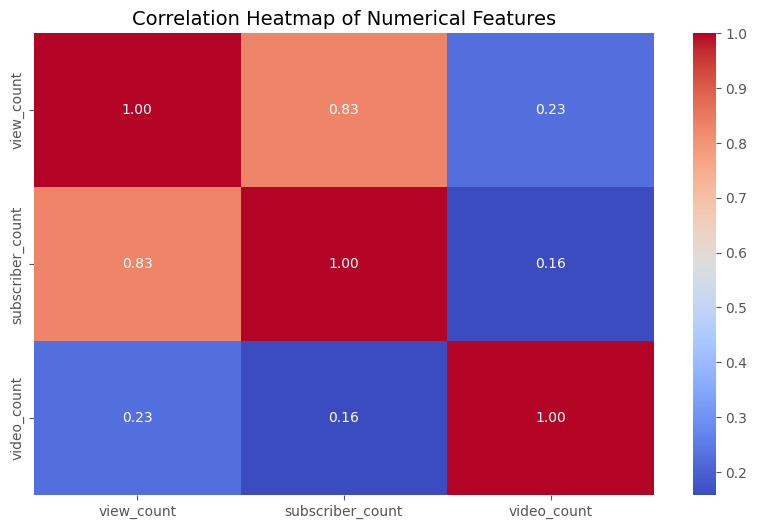

In [14]:
plt.figure(figsize=(10,6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features', fontsize=14)
plt.show()


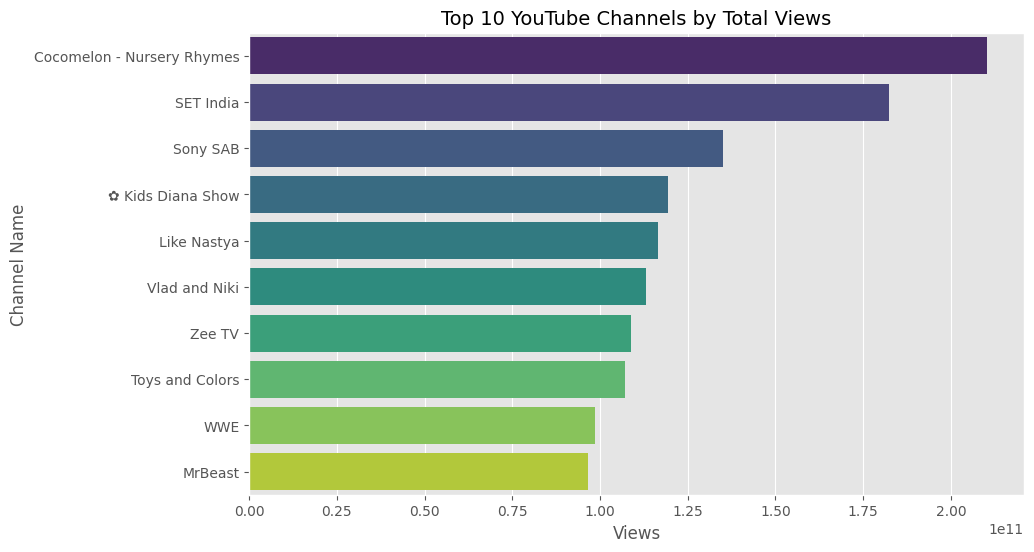

In [20]:
# --- Bar Chart: Top 10 Channels by Views ---
possible_view_cols = [c for c in df.columns if 'view' in c]
possible_name_cols = [c for c in df.columns if 'channel' in c or 'name' in c]

if possible_view_cols and possible_name_cols:
    view_col = possible_view_cols[0]
    name_col = possible_name_cols[0]
    
    top_views = df.sort_values(by=view_col, ascending=False).head(10)
    plt.figure(figsize=(10,6))
    sns.barplot(
        x=view_col,
        y=name_col,
        data=top_views,
        hue=name_col,   # avoids Seaborn warning
        dodge=False,
        legend=False,
        palette='viridis'
    )
    plt.title('Top 10 YouTube Channels by Total Views', fontsize=14)
    plt.xlabel('Views')
    plt.ylabel('Channel Name')
    plt.show()
else:
    print("⚠️ Could not find both 'views' and 'channel name' columns.")


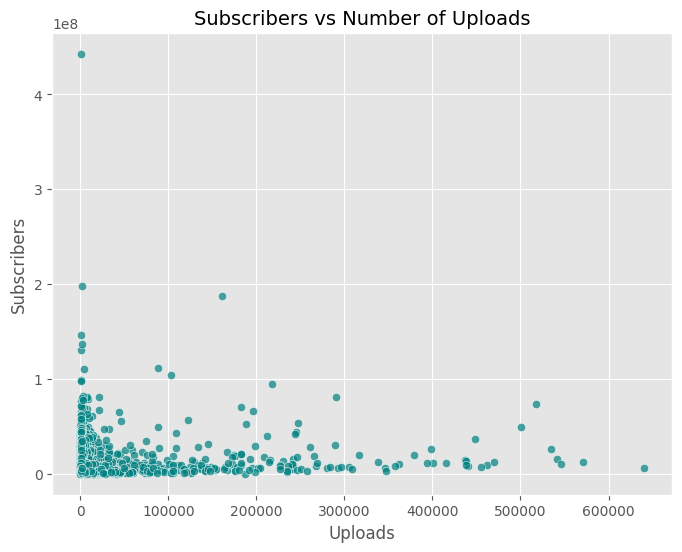

In [21]:

# --- Scatter Plot: Subscribers vs Uploads ---
possible_sub_cols = [c for c in df.columns if 'sub' in c]
possible_upload_cols = [c for c in df.columns if 'upload' in c or 'video' in c]

if possible_sub_cols and possible_upload_cols:
    sub_col = possible_sub_cols[0]
    upload_col = possible_upload_cols[0]
    
    plt.figure(figsize=(8,6))
    sns.scatterplot(
        x=upload_col,
        y=sub_col,
        data=df,
        alpha=0.7,
        color='teal'
    )
    plt.title('Subscribers vs Number of Uploads', fontsize=14)
    plt.xlabel('Uploads')
    plt.ylabel('Subscribers')
    plt.show()
else:
    print("⚠️ Could not find both 'subscribers' and 'uploads' columns.")


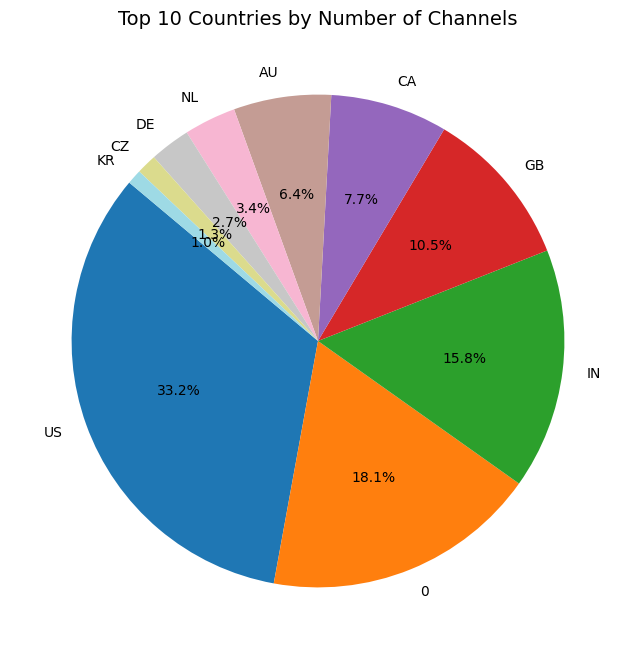

In [23]:
# --- Pie Chart: Top 10 Countries by Number of Channels ---
import matplotlib.pyplot as plt

# Detect a 'country' or 'location'-like column automatically
possible_country_cols = [c for c in df.columns if 'country' in c or 'location' in c]

if possible_country_cols:
    country_col = possible_country_cols[0]
    
    # Get top 10 countries
    top_countries = df[country_col].value_counts().head(10)
    
    plt.figure(figsize=(8,8))
    top_countries.plot.pie(
        autopct='%1.1f%%',
        startangle=140,
        cmap='tab20'
    )
    
    plt.title('Top 10 Countries by Number of Channels', fontsize=14)
    plt.ylabel('')
    plt.show()
else:
    print("⚠️ No 'country' or 'location' column found in dataset.")
